# Numerical solver for the discrete space and structured model

### Preliminary steps

#### Packages

In [171]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.integrate import solve_ivp

#### Parameter class

In [172]:
@dataclass
class Params:
    M: int
    N: int
    kplus: float
    kminus: float
    beta: float
    D_min: float
    gamma: float
    sigma_b: float
    sigma_max: float
    V_tot: float    
    delta_v: float  
    theta: float
    
    debug: bool = False
    tol: float = 1e-6

#### Functions

In [173]:
def compute_v(p: Params) -> np.ndarray:
    """v_n = 1 + n * delta_v"""
    return 1.0 + np.arange(p.N + 1) * p.delta_v

In [463]:
import warnings

def compute_phi(u: np.ndarray, p: Params) -> np.ndarray:
    """
    No-voids constraint:
        phi_i = 1 - sum_n v_n u[i,n]
    """
    v = compute_v(p)
    phi = 1.0 - np.sum(u * v, axis=-1)
    
    # 1. Check for dangerous overshoot before clipping
    min_phi = np.min(phi)
    if min_phi < -1e-6:
        warnings.warn(f"Severe physical violation: phi dropped to {min_phi:.2e}. "
                      f"Grid is over-saturated or solver step is too large.")
    
    # 2. Clip to handle harmless floating-point noise (e.g., -1e-16)
    return np.clip(phi, 0.0, 1.0)

In [175]:
def compute_VL(u: np.ndarray, p: Params):
    n = np.arange(p.N + 1)
    
    # If passed the giant 3D timeline array at the end of the simulation:
    if u.ndim == 3:
        return (p.theta/p.M) * np.sum(u * n, axis=(1, 2))
        
    # If passed a standard 2D spatial grid during the ODE solver:
    else:
        # No axis needed! np.sum() naturally crushes a 2D array into a single float.
        return (p.theta/p.M) * np.sum(u * n)

In [176]:
def linear_decay(x, p:Params):
    return 1 - x / p.N

def linear_growth(x, p:Params):
    return x / p.N

In [177]:
def debug_checks(u: np.ndarray, phi: np.ndarray, Qt: float, p: Params, t: float) -> None:
    """
    Checks that are useful while developing/debugging the model.
    """
    tol = p.tol
    v = compute_v(p)

    if u.shape != (p.M + 1, p.N + 1):
        raise ValueError(f"Bad u shape at t={t}: {u.shape}")

    if not np.all(np.isfinite(u)):
        raise ValueError(f"NaN or inf in u at t={t}")

    if not np.all(np.isfinite(phi)):
        raise ValueError(f"NaN or inf in phi at t={t}")

    if not np.isfinite(Qt):
        raise ValueError(f"NaN or inf in Q at t={t}")

    # Weighted no-voids constraint should keep phi in a physical range
    if np.any(phi < -tol):
        raise ValueError(f"phi < 0 at t={t}; min(phi) = {phi.min()}")

    if np.any(phi > 1.0 + tol):
        raise ValueError(f"phi > 1 at t={t}; max(phi) = {phi.max()}")

    # Optional nonnegativity check on the densities
    if np.any(u < -tol):
        print(f"Warning: negative u at t={t}; min(u) = {u.min()}")

    # Check no-voids identity explicitly
    reconstructed = phi + np.sum(u * v[None, :], axis=1)
    err = np.max(np.abs(reconstructed - 1.0))

    if err > tol:
        raise ValueError(f"No-voids constraint violated at t={t}; max error = {err}")

    # Migration feasibility check, as you described:
    # v_n * v0 / V_box < phi_target
    # V_box = p.L / p.M
    # required_space = v0 * v / V_box

    # Check moves to i+1
    # if p.M >= 1 and np.any(required_space[None, :] >= phi[1:, None] - tol):
    #     raise ValueError(f"Right-move capacity violated at t={t}")

    # Check moves to i-1
    # if p.M >= 1 and np.any(required_space[None, :] >= phi[:-1, None] - tol):
    #     raise ValueError(f"Left-move capacity violated at t={t}")

In [ ]:
def compute_mean_lipid_load_spatial(u: np.ndarray, p: Params) -> np.ndarray:
    """
    Computes:  sum_n(n * u_{i,n}) / sum_n(u_{i,n})
    u shape: (Time, M+1, N+1)
    """
    n_array = np.arange(p.N + 1)  # shape (N+1,)
    
    # Numerator: Sum of packets (n * u_{i,n})
    # np.sum multiplies n_array across the last dimension (classes) and sums it
    total_fraction = np.sum(u * n_array, axis=2) 
    
    # Denominator: Total macrophage concentration (sum of u_{i,n})
    total_concentration = np.sum(u, axis=2)
    
    # Avoid division by zero where concentration is extremely small or zero
    safe_denominator = np.where(total_concentration < 1e-12, 1.0, total_concentration)
    
    # Calculate the mean load and scale by packet volume Δv
    mean_load = (total_fraction / safe_denominator)
    
    # Where concentration is zero, set load to 0
    mean_load = np.where(total_concentration < 1e-12, 0.0, mean_load)
    
    return mean_load

def compute_mean_lipid_load_domain(u: np.ndarray, p: Params) -> np.ndarray:
    """
    Computes the domain-wide mean lipid volume fraction over time.
    Formula: sum_{i,n} ( n * u_{i,n} ) / sum_{i,n} (u_{i,n})
    u shape: (Time, M+1, N+1)
    Returns: 1D array of shape (Time,)
    """
    n_array = np.arange(p.N + 1)  # shape (N+1,)
    
    # Numerator: Weight the fraction by the cell density and sum across SPACE and CLASSES
    # axis=(1, 2) collapses both the spatial grid (M+1) and the lipid classes (N+1)
    total_domain_fraction = np.sum(u * n_array, axis=(1, 2)) 
    
    # Denominator: Total macrophage concentration across the entire domain
    total_domain_macrophages = np.sum(u, axis=(1, 2))
    
    # Avoid division by zero where concentration is extremely small or zero
    safe_denominator = np.where(total_domain_macrophages < 1e-12, 1.0, total_domain_macrophages)
    
    # Calculate the domain-wide mean fraction
    mean_domain_fraction = total_domain_fraction / safe_denominator
    
    # Where concentration is zero, set fraction to 0.0
    mean_domain_fraction = np.where(total_domain_macrophages < 1e-12, 0.0, mean_domain_fraction)
    
    return mean_domain_fraction


### Function for solver

In [178]:
def rhs(t: float, y: np.ndarray, p: Params) -> np.ndarray:
    M, N = p.M, p.N
    u = y.reshape((M + 1, N + 1))

    phi = compute_phi(u, p)
    VLt = compute_VL(u, p)
    v = compute_v(p)

    # ---------------------------------------------------------
    # THE HEAVISIDE MATRIX IMPLEMENTATION
    # ---------------------------------------------------------
    # capacity_val[i, n] checks if state n fits into site i
    capacity_val = (p.V_tot / M) * phi[:, None] - v[None, :]
    
    # H evaluates to 1.0 if it fits, 0.0 if it doesn't
    H = (capacity_val >= 0).astype(float)
    
    # Pre-multiply phi * H for beautifully clean spatial terms
    phi_H = phi[:, None] * H

    if p.debug:
        debug_checks(u, phi, VLt, p, t)

    du = np.zeros_like(u)

    # ---------------------------------------------------------
    # 1) Vectorized interior in i for n = 0
    #    i = 1,...,M-1
    # ---------------------------------------------------------
    if M >= 2:
        du[1:M, 0] = (
            - N * p.kplus * phi[1:M] * u[1:M, 0]
            + p.kminus * u[1:M, 1] 
            + M**2 * (phi_H[1:M, 0] * (u[0:M-1, 0] + u[2:M+1, 0])
                - u[1:M, 0] * (phi_H[0:M-1, 0] + phi_H[2:M+1, 0])
            )
            - p.beta * u[1:M, 0]
        )

    # ---------------------------------------------------------
    # 2) Vectorized interior in i for n = N
    #    i = 1,...,M-1
    # ---------------------------------------------------------
    if M >= 2:
        du[1:M, N] = (
            p.kplus * phi[1:M] * u[1:M, N-1]
            - N * p.kminus * u[1:M, N]
            + M**2 * p.D_min * (
                phi_H[1:M, N] * (u[0:M-1, N] + u[2:M+1, N])
                - u[1:M, N] * (phi_H[0:M-1, N] + phi_H[2:M+1, N])
            )
            - p.beta * u[1:M, N]
        )

    # ---------------------------------------------------------
    # 3) Vectorized boundary row i = 0, for n = 1,...,N-1
    # ---------------------------------------------------------
    if N >= 2:
        n = np.arange(1, N)
        D_n = p.D_min + (1.0 - p.D_min) * linear_decay(n, p)

        du[0, 1:N] = (
            N * p.kplus * phi[0] * (linear_decay(n - 1, p) * u[0, 0:N-1] - linear_decay(n, p) * u[0, 1:N])
            + N * p.kminus * (linear_growth(n + 1, p) * u[0, 2:N+1] - linear_growth(n, p) * u[0, 1:N])
            + M**2 * D_n * (phi_H[0, 1:N] * u[1, 1:N] - phi_H[1, 1:N] * u[0, 1:N])
            - p.beta * u[0, 1:N]
        )

        # ---------------------------------------------------------
        # 4) Vectorized boundary row i = M, for n = 1,...,N-1
        # ---------------------------------------------------------
        du[M, 1:N] = (
            N * p.kplus * phi[M] * (linear_decay(n - 1, p) * u[M, 0:N-1] - linear_decay(n, p) * u[M, 1:N])
            + N * p.kminus * (linear_growth(n + 1, p) * u[M, 2:N+1] - linear_growth(n, p) * u[M, 1:N])
            + M**2 * D_n * (phi_H[M, 1:N] * u[M-1, 1:N] - phi_H[M-1, 1:N] * u[M, 1:N] )
            - M * p.gamma * D_n * u[M, 1:N]
            - p.beta * u[M, 1:N]
        )

        # ---------------------------------------------------------
        # 5) Full interior block: 1 <= i <= M-1, 1 <= n <= N-1
        # ---------------------------------------------------------
        if M >= 2:
            D_n_2d = p.D_min + (1.0 - p.D_min) * linear_decay(n, p)[None, :]
            du[1:M, 1:N] = (
                N * p.kplus * phi[1:M, None] * (
                    linear_decay(n - 1, p)[None, :] * u[1:M, 0:N-1]
                    - linear_decay(n, p)[None, :] * u[1:M, 1:N]
                )
                + N * p.kminus * (
                    linear_growth(n + 1, p)[None, :] * u[1:M, 2:N+1]
                    - linear_growth(n, p)[None, :] * u[1:M, 1:N]
                )
                + M**2 * D_n_2d * (
                    phi_H[1:M, 1:N] * (u[0:M-1, 1:N] + u[2:M+1, 1:N])
                    - u[1:M, 1:N] * (phi_H[0:M-1, 1:N] + phi_H[2:M+1, 1:N])
                )
                - p.beta * u[1:M, 1:N]
            )

    # ---------------------------------------------------------
    # 6) Corners
    # ---------------------------------------------------------
    du[0, 0] = (
        - N * p.kplus * phi[0] * u[0, 0]
        + p.kminus * u[0, 1]
        + M * (p.sigma_b + p.sigma_max * VLt / (1.0 + VLt)) * phi_H[0, 0]
        + M**2 * (phi_H[0, 0] * u[1, 0] - phi_H[1, 0] * u[0, 0])
        - p.beta * u[0, 0]
    )

    du[0, N] = (
        p.kplus * phi[0] * u[0, N-1]
        - N * p.kminus * u[0, N]
        + M**2 * p.D_min * (phi_H[0, N] * u[1, N] - phi_H[1, N] * u[0, N])
        - p.beta * u[0, N]
    )

    du[M, 0] = (
        - N * p.kplus * phi[M] * u[M, 0]
        + p.kminus * u[M, 1]
        + M**2 * (phi_H[M, 0] * u[M-1, 0] - phi_H[M-1, 0] * u[M, 0])
        - M * p.gamma * u[M, 0]
        - p.beta * u[M, 0]
    )

    du[M, N] = (
        p.kplus * phi[M] * u[M, N-1]
        - N * p.kminus * u[M, N]
        + M**2 * p.D_min * (phi_H[M, N] * u[M-1, N] - phi_H[M-1, N] * u[M, N])
        - M * p.gamma * p.D_min * u[M, N]
        - p.beta * u[M, N]
    )

    if p.debug:
        if not np.all(np.isfinite(du)):
            raise ValueError(f"NaN or inf in du at t={t}")

    return du.ravel()

### Model solver

We define the parameter values

In [756]:
p = Params(
    M=50,
    N=100,
    kplus=1,
    kminus=1,
    beta=2,
    D_min=0.1,
    gamma=0.2,
    sigma_b=0.004,
    sigma_max=0.4,
    V_tot=100000,
    delta_v=0.005,
    theta=1,
    debug=True
)

We set initial conditions and the time span more the solver

In [ ]:
# Initial condition: u
u0 = np.zeros((p.M + 1, p.N + 1)) #1/(p.N*p.M) * np.ones((p.M + 1, p.N + 1))
v = compute_v(p)
phi_initial = 1.0 - np.sum(u0 * v[None, :], axis=1)
if np.any(phi_initial < -p.tol):
        raise ValueError(f"phi_initial < 0 at t=0; min(phi) = {phi_initial.min()}")

y0 = u0.ravel()

# Time interval
t_final = 20.0
t_span = (0.0, t_final)
t_eval = np.linspace(t_span[0], t_span[1], 500)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1.]
(51,)


The following function serves to generate the Jacobian sparsity matrix for the model to increase the speed of the solver

In [760]:
from scipy.sparse import kron, diags

def build_sparsity_matrix(p):
    """
    Generates the Jacobian sparsity matrix for the atherosclerosis model.
    1 means the variables interact, 0 means they do not.
    """
    # 1. Spatial Grid (Tridiagonal)
    # Each site i interacts with i-1, i, and i+1.
    # We make a tridiagonal matrix of size (M+1) x (M+1)
    spatial_diags = [np.ones(p.M), np.ones(p.M + 1), np.ones(p.M)]
    spatial_sparse = diags(spatial_diags, offsets=[-1, 0, 1], format='csr')

    # 2. Lipid/Volume Block (Dense)
    # Because of phi_i, every lipid class at a specific site interacts 
    # with every other lipid class at that same site.
    # We make a dense matrix of size (N+1) x (N+1)
    lipid_dense = np.ones((p.N + 1, p.N + 1))

    # 3. The Kronecker Product
    # This magically copies the dense lipid block into the tridiagonal spatial slots!
    jac_sparsity = kron(spatial_sparse, lipid_dense, format='lil')

    # 4. The Global Inflammation Feedback (Q)
    # The very first variable in the flattened array is u_{0,0}.
    # Its derivative depends on the recruitment term, which uses Q(t).
    # Since Q(t) sums over the whole domain, row 0 depends on EVERYTHING.
    jac_sparsity[0, :] = 1

    # Convert back to Compressed Sparse Row (CSR) format for maximum solver speed
    return jac_sparsity.tocsr()

# Generate the sparsity matrix
jac_sparsity = build_sparsity_matrix(p)

We solve the model and store its final output

In [761]:
# Solve
sol = solve_ivp(
    fun=lambda t, y: rhs(t, y, p),
    t_span=t_span,
    y0=y0,
    t_eval=t_eval,
    method="BDF",
    jac_sparsity=jac_sparsity,
    rtol=1e-6,
    atol=1e-9,
)

print("Success:", sol.success)
print(sol.message)

# Reshape solution back to (time, i, n)
U = sol.y.T.reshape((-1, p.M + 1, p.N + 1)) # shape (time, M+1, N+1)
#print("U shape:", U.shape)

Success: True
The solver successfully reached the end of the integration interval.


### Useful quantities

In [ ]:
n_array = np.arange(p.N + 1)  # shape (N+1,)
i_array = np.arange(p.M + 1)  # shape (M+1,)
v_n = compute_v(p)  # shape (N+1,)

# SPATIAL PROFILES
# Dimensionless number density of macrophages over space: sum_n u[i,n]
cellular_number_density_spatial = np.sum(U, axis=2) # shape (time, M+1)
# Volume fraction of macrophages over space: sum_n (v_n * u[i,n])
cellular_volume_fraction_spatial = np.sum(U * v_n, axis=2) # shape (time, M+1)
# Total number of macrophages over space: sum_n V_tot/M * u[i,n]
macrophage_number_spatial = (p.V_tot / p.M) * cellular_number_density_spatial # shape (time, M+1)
# Mean lipid load per macrophage over space: sum_n (n * u[i,n]) / sum_n u[i,n]
mean_lipid_load_spatial = compute_mean_lipid_load_spatial(U, p) # shape (time, M+1)
# Extracellular fluid volume fraction over space: phi[i] = 1 - sum_n (v_n * u[i,n])
phi = compute_phi(U, p) # shape (time, M+1)

# STRUCTURE PROFILES
# Distribution of macrophages number density: sum_i u[i,n] 
cellular_number_density_distribution = np.sum(U, axis=1) # shape (time, N+1)
# Distribution of macrophages volume fraction: sum_i (v_n * u[i,n])
cellular_volume_fraction_distribution = np.sum(U * v_n, axis=1) # shape (time, N+1)
# Distribution of number of macrophages: sum_i V_tot/M * u[i,n]
macrophage_number_distribution = (p.V_tot / p.M) * cellular_number_density_distribution # shape (time, N+1)

# TOTAL QUANTITIES OVER TIME
# Total dimensionless number of macrophages: sum_i sum_n u[i,n]
total_cellular_number_density = np.sum(U, axis=(1, 2)) # shape (time,)
# Total volume fraction of macrophages: sum_i sum_n (v_n * u[i,n])
total_cellular_volume_fraction = np.sum(U * v_n, axis=(1, 2)) # shape (time,)
# Total number of macrophages: sum_i sum_n V_tot/M * u[i,n]
total_macrophage_number = (p.V_tot / p.M) * total_cellular_number_density # shape (time,)
# Total mean lipid load per macrophage: sum_i sum_n (n * u[i,n]) / sum_i sum_n u[i,n]
total_mean_lipid_load = compute_mean_lipid_load_domain(U, p) # shape (time,)
# Total internalised lipid volume: V_L(t)
total_internalised_lipid_volume = compute_VL(U, p) # shape (time,)

i_array shape: (51,)
cellular_volume_fraction_spatial shape: (500, 51)
phi shape: (500, 51)


### Plotting

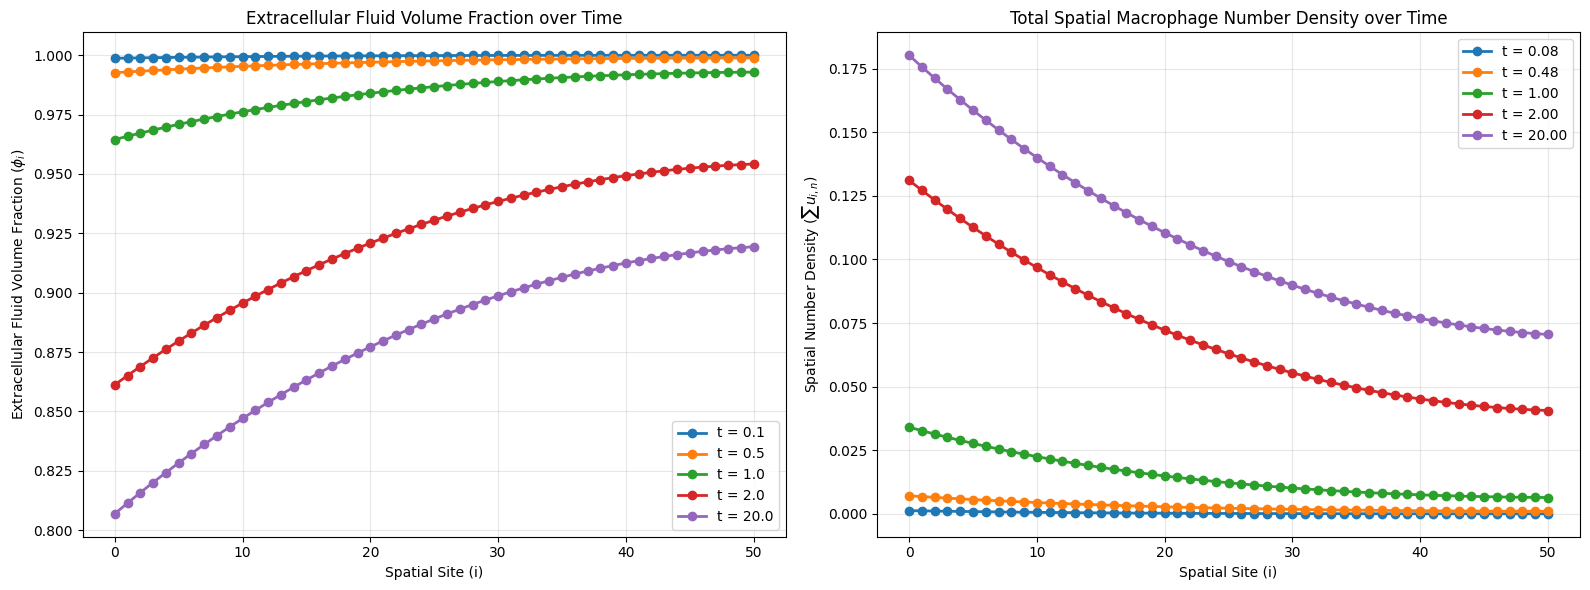

In [764]:
times_to_plot = [0.1, 0.5, 1, 2, t_final]

# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for target_t in times_to_plot:
    idx = np.argmin(np.abs(sol.t - target_t))
    actual_t = sol.t[idx]
    
    # Data for this time step
    phi_at_target_t = phi[idx, :] 
    macrophage_density = cellular_number_density_spatial[idx, :]
    
    # Panel 1: Free Space (phi)
    ax1.plot(i_array, phi_at_target_t, 
             label=f"t = {actual_t:.1f}", linewidth=2, marker='o')
             
    # Panel 2: Total Macrophages
    ax2.plot(i_array, macrophage_density, 
             label=f"t = {actual_t:.2f}", linewidth=2, marker='o')

# Format Panel 1
ax1.set_xlabel("Spatial Site (i)")
ax1.set_ylabel(r"Extracellular Fluid Volume Fraction ($\phi_i$)")
ax1.set_title("Extracellular Fluid Volume Fraction over Time")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Format Panel 2
ax2.set_xlabel("Spatial Site (i)")
ax2.set_ylabel(r"Spatial Number Density ($\sum u_{i,n}$)")
ax2.set_title("Total Spatial Macrophage Number Density over Time")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

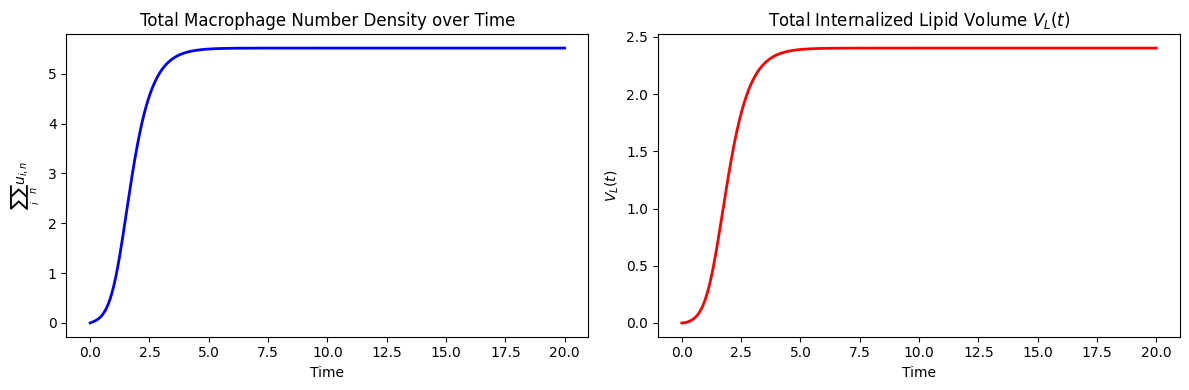

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(sol.t, total_cellular_number_density, color='blue', linewidth=2)
ax[0].set_title("Total Macrophage Number Density over Time")
ax[0].set_xlabel("Time")
ax[0].set_ylabel(r"$\sum_i \sum_n u_{i,n}$")

ax[1].plot(sol.t, total_internalised_lipid_volume, color='red', linewidth=2)
ax[1].set_title("Total Internalized Lipid Volume $V_L(t)$")
ax[1].set_xlabel("Time")
ax[1].set_ylabel(r"$V_L(t)$")

plt.tight_layout()
plt.show()

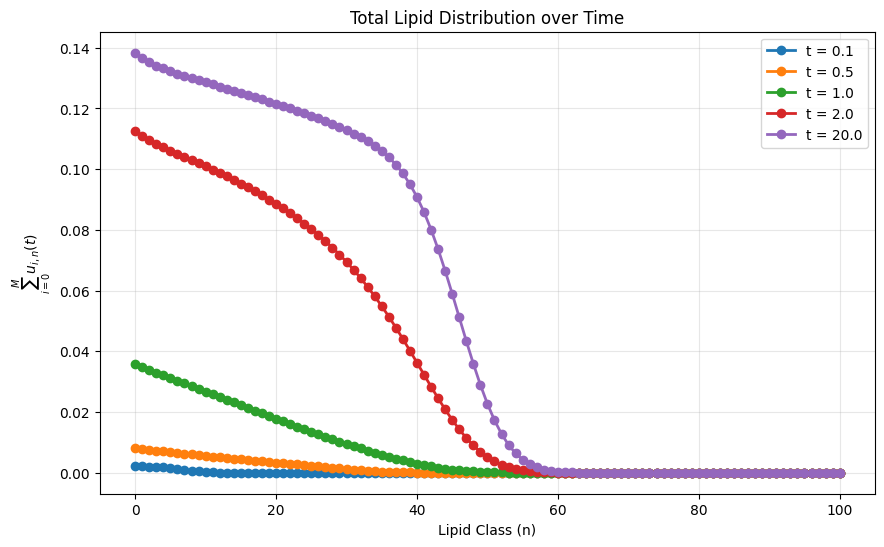

In [768]:
# PLOT DISTRIBUTION OF TOTAL SPATIAL DENSITY OVER TIME
# 1. Sum across all spatial classes (axis 1) to get total spatial density
total_density_lipid = np.sum(U, axis=1) # Shape: (Time, N+1)

plt.figure(figsize=(10, 6))

for target_t in times_to_plot:
    # Find the index of the time step closest to our target_t
    idx = np.argmin(np.abs(sol.t - target_t))
    actual_t = sol.t[idx]
    # Plot the total lipid distribution at that specific time
    plt.plot(np.arange(p.N + 1), total_density_lipid[idx, :],
             label=f"t = {actual_t:.1f}", linewidth=2, marker='o')

plt.xlabel("Lipid Class (n)")
plt.ylabel(r"$\sum_{i=0}^{M} u_{i,n}(t)$")
plt.title(r"Total Lipid Distribution over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
class MyClass:
    def __init__(self, param1, param2):
        self.param1 = param1
        self.param2 = param2
    
    def method1(self):
        return self.param1 + self.param2
    
    def method2(self):
        return self.param1 * self.param2

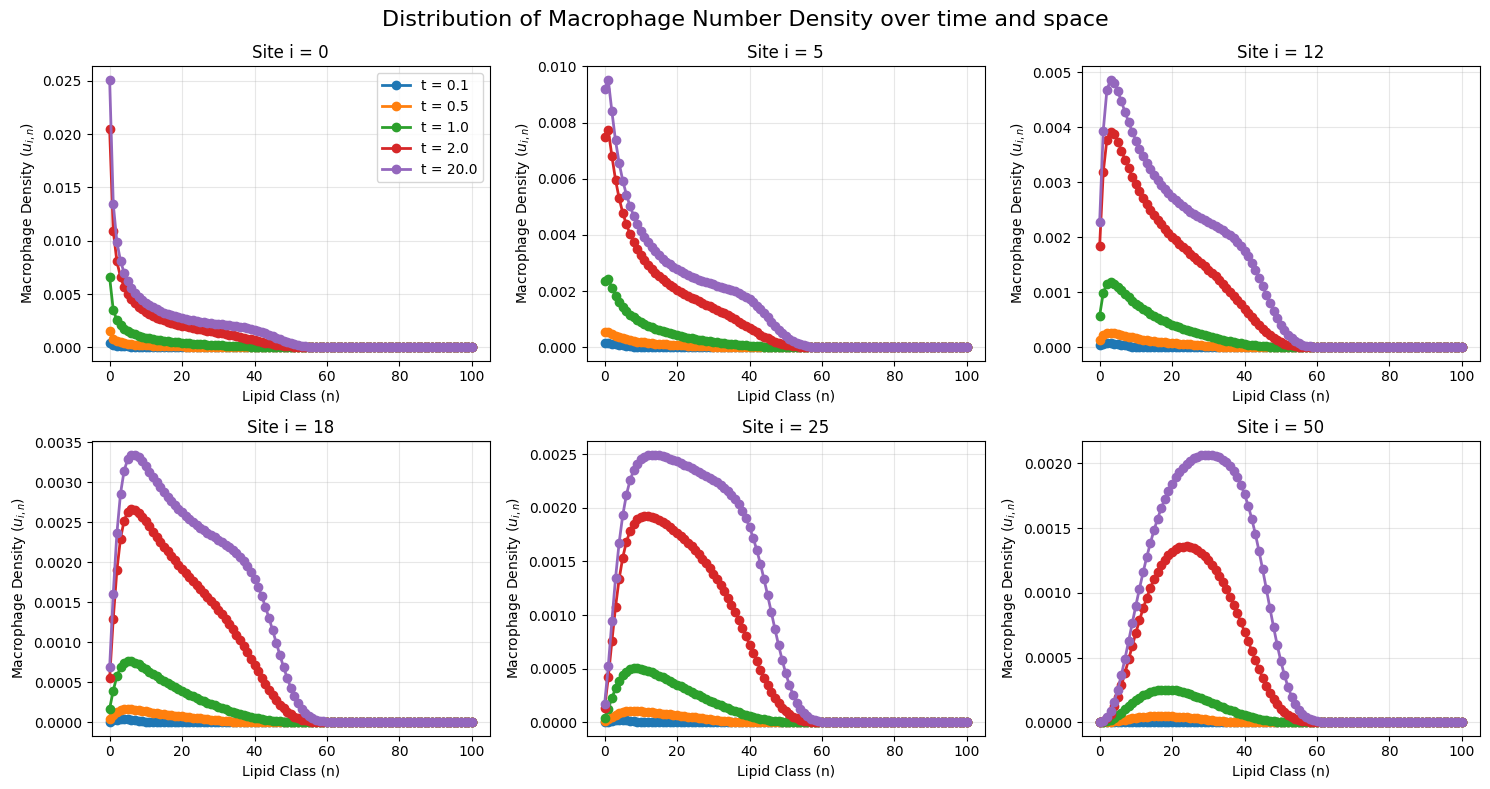

In [769]:
# PLOT LIPID DISTRIBUTION AT SOME SPATIAL SITES AT FINAL TIME
import math

u_final = U[-1, :, :] # Shape: (M+1, N+1)
n_grid = np.arange(p.N + 1)

# Pick a few spatial points to plot
spatial_sites_to_plot = [0, int(p.M * 0.1), int(p.M * 0.25), int(p.M * 0.37), int(p.M * 0.5), p.M]
num_plots = len(spatial_sites_to_plot)

# 1. Dynamically calculate grid size (Let's set a max of 3 columns)
ncols = min(3, num_plots)
nrows = math.ceil(num_plots / ncols)

# 2. Create the grid with a dynamic figsize
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

# Flatten axes to 1D array for easy looping (handles the 1-plot edge case)
if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# 3. Loop through the sites and plot them
for idx, site in enumerate(spatial_sites_to_plot):
    ax = axes[idx]
    
    # Ensure we don't ask for a site larger than the grid
    safe_site = min(site, p.M)

    for target_t in times_to_plot:
    # Find the index of the time step closest to our target_t
        idx = np.argmin(np.abs(sol.t - target_t))
        actual_t = sol.t[idx]
    
        ax.plot(n_grid, U[idx, safe_site, :], label=f"t = {actual_t:.1f}", linewidth=2, marker='o')
        ax.set_title(f"Site i = {safe_site}")
        ax.set_xlabel("Lipid Class (n)")
        ax.set_ylabel(r"Macrophage Density ($u_{i,n}$)")
        ax.grid(True, alpha=0.3)

# 4. Hide any unused empty subplots at the end of the grid
for empty_idx in range(num_plots, len(axes)):
    axes[empty_idx].set_visible(False)

# Add title and automatically adjust layout
fig.suptitle(f"Distribution of Macrophage Number Density over time and space", fontsize=16)
axes[0].legend()
plt.tight_layout()
plt.show()



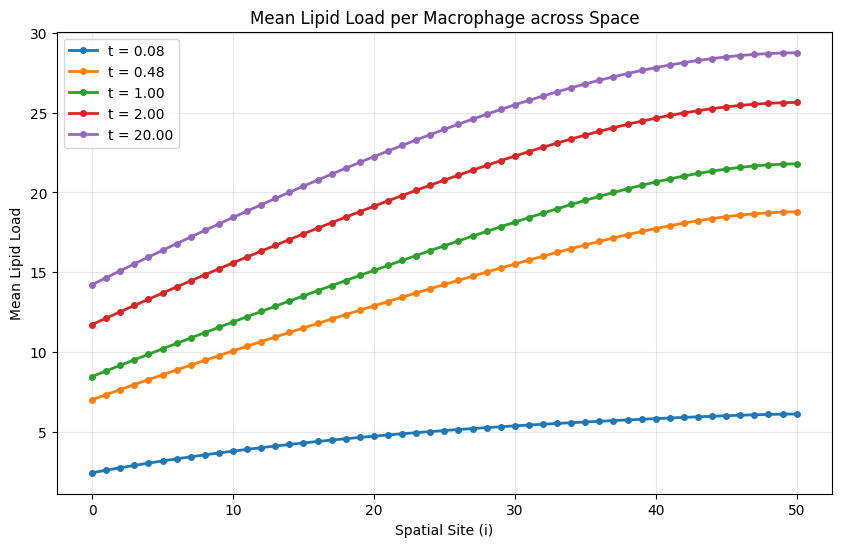

In [770]:
# PLOT THE MEAN LIPID LOAD OVER SPACE AT SOME TIME STEPS
plt.figure(figsize=(10, 6))

for target_t in times_to_plot:
    # Find the index of the time step closest to our target_t
    idx = np.argmin(np.abs(sol.t - target_t))
    actual_t = sol.t[idx]
    
    # Plot the mean lipid load across the spatial grid at this time
    plt.plot(np.arange(p.M + 1), mean_lipid_load_spatial[idx, :],
             label=f"t = {actual_t:.2f}", linewidth=2, marker='o', markersize=4)

plt.xlabel("Spatial Site (i)")
plt.ylabel(r"Mean Lipid Load") # Or appropriate volume unit based on delta_v
plt.title(r"Mean Lipid Load per Macrophage across Space")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [771]:
# def rhs_augmented(t, y, p):
#     # 1. Unpack the state vector into u and phi_ode
#     num_u = (p.M + 1) * (p.N + 1)
    
#     M = p.M
#     N = p.N

#     u_flat = y[:num_u]
#     phi_ode = y[num_u:]  # The solver's integrated version of phi_ode
    
#     u = u_flat.reshape((p.M + 1, p.N + 1))
    
#     # 2. Compute du/dt EXACTLY as you normally do.
#     # CRITICAL: Pass `phi_ode` into your equations instead of computing 
#     # it algebraically so we test the ODE's actual performance!
#     du = np.zeros_like(u)
    
#     VLt = compute_VL(u, p)

#     if p.debug:
#         debug_checks(u, phi_ode, VLt, p, t)

#     du = np.zeros_like(u)

#        # ---------------------------------------------------------
#     # 1) Vectorized interior in i for n = 0
#     #    i = 1,...,M-1
#     # ---------------------------------------------------------
#     if M >= 2:
#         du[1:M, 0] = (
#             - N * p.kplus * phi_ode[1:M] * u[1:M, 0]
#             + p.kminus * u[1:M, 1] 
#             + M**2 * p.mu_max * (
#                 phi_ode[1:M] * (u[0:M-1, 0] + u[2:M+1, 0])
#                 - u[1:M, 0] * (phi_ode[0:M-1] + phi_ode[2:M+1])
#             )
#             - u[1:M, 0]
#         )

#     # ---------------------------------------------------------
#     # 2) Vectorized interior in i for n = N
#     #    i = 1,...,M-1
#     # ---------------------------------------------------------
#     if M >= 2:
#         du[1:M, N] = (
#             p.kplus * phi_ode[1:M] * u[1:M, N-1]
#             - N * p.kminus * u[1:M, N]
#             + M**2 * p.mu_min * (
#                 phi_ode[1:M] * (u[0:M-1, N] + u[2:M+1, N])
#                 - u[1:M, N] * (phi_ode[0:M-1] + phi_ode[2:M+1])
#             )
#             - u[1:M, N]
#         )

#     # ---------------------------------------------------------
#     # 3) Vectorized boundary row i = 0, for n = 1,...,N-1
#     # ---------------------------------------------------------
#     if N >= 2:
#         n = np.arange(1, N)
#         k_up = lambda x: 1 - x / N
#         k_down = lambda x: x / N

#         du[0, 1:N] = (
#             N * p.kplus * phi_ode[0] * (k_up(n - 1) * u[0, 0:N-1] - k_up(n) * u[0, 1:N])
#             + N * p.kminus * (k_down(n + 1) * u[0, 2:N+1] - k_down(n) * u[0, 1:N])
#             + M**2 * (p.mu_min + (p.mu_max - p.mu_min) * k_up(n))
#             * (phi_ode[0] * u[1, 1:N] - phi_ode[1] * u[0, 1:N])
#             - u[0, 1:N]
#         )

#         # ---------------------------------------------------------
#         # 4) Vectorized boundary row i = M, for n = 1,...,N-1
#         # ---------------------------------------------------------
#         du[M, 1:N] = (
#             N * p.kplus * phi_ode[M] * (k_up(n - 1) * u[M, 0:N-1] - k_up(n) * u[M, 1:N])
#             + N * p.kminus * (k_down(n + 1) * u[M, 2:N+1] - k_down(n) * u[M, 1:N])
#             + M**2 * (p.mu_min + (p.mu_max - p.mu_min) * k_up(n))
#             * (phi_ode[M] * u[M-1, 1:N] - phi_ode[M-1] * u[M, 1:N] )
#             - M (p.gamma_min + (p.gamma_max - p.gamma_min) * k_up(n)) * u[M, 1:N]
#             - u[M, 1:N]
#         )

#         # ---------------------------------------------------------
#         # 5) Full interior block: 1 <= i <= M-1, 1 <= n <= N-1
#         # ---------------------------------------------------------
#         if M >= 2:
#             du[1:M, 1:N] = (
#                 N * p.kplus * phi_ode[1:M, None] * (
#                     k_up(n - 1)[None, :] * u[1:M, 0:N-1]
#                     - k_up(n)[None, :] * u[1:M, 1:N]
#                 )
#                 + N * p.kminus * (
#                     k_down(n + 1)[None, :] * u[1:M, 2:N+1]
#                     - k_down(n)[None, :] * u[1:M, 1:N]
#                 )
#                 + M**2 * (p.mu_min + (p.mu_max - p.mu_min) * k_up(n))[None, :] * (
#                     phi_ode[1:M, None] * (u[0:M-1, 1:N] + u[2:M+1, 1:N])
#                     - u[1:M, 1:N] * (phi_ode[0:M-1, None] + phi_ode[2:M+1, None])
#                 )
#                 - u[1:M, 1:N]
#             )

#     # ---------------------------------------------------------
#     # 6) Corners
#     # ---------------------------------------------------------
#     du[0, 0] = (
#         - N * p.kplus * phi_ode[0] * u[0, 0]
#         + p.kminus * u[0, 1]
#         + M * (p.sigma + p.g_max * Qt / (p.Q_star + Qt)) * phi_ode[0]
#         + M**2 * p.mu_max * (phi_ode[0] * u[1, 0] - phi_ode[1] * u[0, 0])
#         - u[0, 0]
#     )

#     du[0, N] = (
#         p.kplus * phi_ode[0] * u[0, N-1]
#         - N * p.kminus * u[0, N]
#         + M**2 * p.mu_min * (phi_ode[0] * u[1, N] - phi_ode[1] * u[0, N])
#         - u[0, N]
#     )

#     du[M, 0] = (
#         - N * p.kplus * phi_ode[M] * u[M, 0]
#         + p.kminus * u[M, 1]
#         + M**2 * p.mu_max * (phi_ode[M] * u[M-1, 0] - phi_ode[M-1] * u[M, 0])
#         - M * p.gamma_max * u[M, 0]
#         - u[M, 0]
#     )

#     du[M, N] = (
#         p.kplus * phi_ode[M] * u[M, N-1]
#         - N * p.kminus * u[M, N]
#         + M**2 * p.mu_min * (phi_ode[M] * u[M-1, N] - phi_ode[M-1] * u[M, N])
#         - M * p.gamma_min * u[M, N]
#         - u[M, N]
#     )
    
#     # 3. Compute dphi_ode/dt directly using the derived volume relationship
#     # d(phi_ode_i)/dt = - sum_n( v_n * d(u_{i,n})/dt )
#     v = compute_v(p) # Your array of volumes
#     dphi_ode = -np.sum(du * v[None, :], axis=1)

#     if p.debug:
#         if not np.all(np.isfinite(du)):
#             raise ValueError(f"NaN or inf in du at t={t}")
        
#     if p.debug:
#         if not np.all(np.isfinite(dphi_ode)):
#             raise ValueError(f"NaN or inf in dphi_ode at t={t}")
    
#     # 4. Pack them back together into a flat 1D array
#     return np.concatenate([du.ravel(), dphi_ode])

In [772]:
from scipy.sparse import bmat, diags, kron

def build_augmented_sparsity(p):
    # 1. Top-Left Block (du/du): The original (M+1)*(N+1) x (M+1)*(N+1) grid
    # We can safely reuse the exact same sparsity structure we already built!
    J_uu = build_sparsity_matrix(p) 

    # We need a spatial tridiagonal footprint because cells jump between i-1, i, and i+1
    spatial_tridiag = diags([np.ones(p.M), np.ones(p.M+1), np.ones(p.M)], offsets=[-1, 0, 1])

    # 2. Top-Right Block (du/dphi): How do cells react to free space?
    # du_{i}/dt depends on phi_{i-1}, phi_i, and phi_{i+1} for jumping.
    # Shape: ((M+1)*(N+1), M+1)
    lipid_col = np.ones((p.N + 1, 1))
    J_u_phi = kron(spatial_tridiag, lipid_col, format='csr')

    # 3. Bottom-Left Block (dphi/du): How does free space react to cells?
    # dphi/dt = -sum(v * du/dt). Because it is a direct sum of du/dt, 
    # it perfectly inherits the exact same spatial dependencies as u.
    # Shape: (M+1, (M+1)*(N+1))
    lipid_row = np.ones((1, p.N + 1))
    J_phi_u = kron(spatial_tridiag, lipid_row, format='lil')
    
    # Don't forget the Q(t) global inflammation feedback at the entrance!
    # dphi_0/dt depends on du_0/dt, which depends on Q(t), which depends on ALL u.
    J_phi_u[0, :] = 1
    J_phi_u = J_phi_u.tocsr()

    # 4. Bottom-Right Block (dphi/dphi): How does free space react to free space?
    # Since dphi/dt depends on du/dt, and du/dt depends on phi, dphi/dt depends on phi.
    # Shape: (M+1, M+1)
    J_phi_phi = spatial_tridiag.copy()

    # 5. Glue them all together into the final Augmented Jacobian!
    jac_augmented = bmat([
        [J_uu,    J_u_phi],
        [J_phi_u, J_phi_phi]
    ], format='csr')

    return jac_augmented

# Generate the augmented sparsity matrix
jac_sparsity_aug = build_augmented_sparsity(p)

In [773]:
# # 1. Initialize u0
# u0 = np.zeros((p.M + 1, p.N + 1))
# # (Add any initial seeds here if you have them)

# # 2. Calculate the exact algebraic phi0
# phi0 = compute_phi(u0, p) 

# # 3. Combine them into the augmented initial state vector
# y0_augmented = np.concatenate([u0.flatten(), phi0])

# # Run the solver
# sol_augmented = solve_ivp(
#     fun=lambda t, y: rhs_augmented(t, y, p),
#     t_span=t_span,
#     y0=y0_augmented,
#     t_eval=t_eval,
#     method="BDF",
#     jac_sparsity=jac_sparsity_aug,
#     rtol=1e-6,
#     atol=1e-9
# )

In [774]:
# # 1. Extract final state
# num_u = (p.M + 1) * (p.N + 1)

# u_final_flat = sol_augmented.y[:num_u, -1]
# u_final = u_final_flat.reshape((p.M + 1, p.N + 1))
# u_final_algebraic = U[-1, :, :] # From the original ODE solution

# phi_integrated_final = sol_augmented.y[num_u:, -1] # From solving the ODE

# # 2. Compute algebraic phi from the final u
# phi_algebraic_final = compute_phi(u_final_algebraic, p)

# # 3. Calculate the absolute error between the two methods
# error = np.abs(phi_integrated_final - phi_algebraic_final)
# max_error = np.max(error)

# print(f"Maximum absolute difference between ODE and Algebraic phi: {max_error:.2e}")

# # 4. Plot the comparison
# i_grid = np.arange(p.M + 1)

# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # Plot A: Both Curves overlayed (they should overlap perfectly)
# axes[0].plot(i_grid, phi_algebraic_final, label="Algebraic Constraint", color='blue', marker='o')
# axes[0].plot(i_grid, phi_integrated_final, label="Integrated ODE", color='red', marker='x', markersize=8)
# axes[0].set_title(r"Overlay of $\phi_i$ Solutions")
# axes[0].set_xlabel("Spatial Site (i)")
# axes[0].set_ylabel(r"$\phi_i$")
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# # Plot B: The numerical error
# axes[1].plot(i_grid, error, color='purple', marker='o', markersize=4)
# axes[1].set_title("Absolute Error between Methods")
# axes[1].set_xlabel("Spatial Site (i)")
# axes[1].set_ylabel("Error magnitude")
# axes[1].set_yscale('log') # Log scale is great for viewing tiny numerical noise
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [775]:
# # ==========================================
# # 1. RUN SIMULATION FOR M = 50
# # ==========================================
# p50 = Params(
#     M=50,       
#     N=50,         
#     kplus=1.0,  
#     kminus=0.1,   
#     mu_max=0.8,   
#     mu_min=0.04, 
#     gamma_IEL=2.5, 
#     sigma=0.001,    
#     g_max=0.1,     
#     Q_star=0.00002,  
#     L=1.0, 
#     V_max=2.0,    
#     debug=True,
#     tol=1e-5
# )


# # Build, solve, and extract for M=50
# y0_50 = np.zeros((p50.M + 1) * (p50.N + 1))
# jac_50 = build_sparsity_matrix(p50)
# sol_50 = solve_ivp(
#     fun=lambda t, y: rhs(t, y, p50),
#     t_span=(0, 5.0),  # Adjust final time if needed
#     y0=y0_50,
#     method="BDF",
#     jac_sparsity=jac_50
# )

# # Extract final state arrays for M=50
# U_50 = sol_50.y[:, -1].reshape((p50.M + 1, p50.N + 1))
# phi_50 = compute_phi(U_50, p50)
# total_u_50 = np.sum(U_50, axis=1)

# # Create the PHYSICAL spatial x-axis for M=50 (from 0.0 to 1.0)
# x_50 = np.linspace(0, p50.L, p50.M + 1)

# # ==========================================
# # 2. RUN SIMULATION FOR M = 100
# # ==========================================
# scaling_factor = 4.0
# p100 = Params(
#     M=100,       
#     N=100,         
#     kplus=1.0,  
#     kminus=0.1,   
#     mu_max=0.8,   
#     mu_min=0.04, 
#     gamma_IEL=2.5, 
#     sigma=0.001,    
#     g_max=0.1,     
#     Q_star=0.00002,  
#     L=1.0, 
#     V_max=2.0,    
#     debug=True,
#     tol=1e-5
# )

# # Build, solve, and extract for M=100
# y0_100 = np.zeros((p100.M + 1) * (p100.N + 1))
# jac_100 = build_sparsity_matrix(p100)
# sol_100 = solve_ivp(
#     fun=lambda t, y: rhs(t, y, p100),
#     t_span=(0, 5.0),
#     y0=y0_100,
#     method="BDF",
#     jac_sparsity=jac_100
# )

# # Extract final state arrays for M=100
# U_100 = sol_100.y[:, -1].reshape((p100.M + 1, p100.N + 1))
# phi_100 = compute_phi(U_100, p100)
# total_u_100 = np.sum(U_100, axis=1)

# # Create the PHYSICAL spatial x-axis for M=100 (from 0.0 to 1.0)
# x_100 = np.linspace(0, p100.L, p100.M + 1)

# # ==========================================
# # 3. PLOT THE COMPARISON
# # ==========================================
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# # --- Panel 1: Free Space (phi) ---
# ax1.plot(x_50, phi_50, color='blue', linewidth=2, label="M=50,N=50", marker='o')
# ax1.plot(x_100, phi_100, color='red', linewidth=2, linestyle='--', label="M=100,N=100", marker='s')
# ax1.set_title("Free Space at t = 5.0")
# ax1.set_xlabel("Physical Distance across Artery Wall (x)")
# ax1.set_ylabel(r"Free Space ($\phi$)")
# ax1.grid(True, alpha=0.3)
# ax1.legend()

# # --- Panel 2: Total Macrophages ---
# ax2.plot(x_50, total_u_50, color='blue', linewidth=2, label="M=50,N=50", marker='o')
# ax2.plot(x_100, total_u_100, color='red', linewidth=2, linestyle='--', label="M=100,N=100", marker='s')
# ax2.set_title("Total Macrophages at t = 5.0")
# ax2.set_xlabel("Physical Distance across Artery Wall (x)")
# ax2.set_ylabel(r"Total Cells ($\sum u_{i,n}$)")
# ax2.grid(True, alpha=0.3)
# ax2.legend()

# plt.tight_layout()
# plt.show()